<a href="https://colab.research.google.com/github/codebender04/DL4AI-230087-project/blob/main/final_project_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [1]:
# ============================================================
# GLOBAL IMPORTS & SETTINGS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, glob, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense, LSTM,
    Dropout, BatchNormalization, Input
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# TASK 1 — Nasdaq Stock Price Prediction (AAPL)
---

## Task 1.0 — Load & Explore Data

In [29]:
# ── Load AAPL data ──────────────────────────────────────────
# Adjust this path to where your Nasdaq CSV files are located
NASDAQ_DATA_PATH = './csv'          # folder with Nasdaq CSVs
VIETNAM_DATA_PATH = '.'             # root folder of Vietnam data

df_aapl = pd.read_csv('/content/drive/MyDrive/DL4AI-project/AAPL.csv')   # sample file provided
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'], dayfirst=True)
df_aapl = df_aapl.sort_values('Date').reset_index(drop=True)
CUTOFF = df_aapl['Date'].max() - pd.DateOffset(years=10)
df_aapl = df_aapl[df_aapl['Date'] >= CUTOFF].reset_index(drop=True)

print(f'Using {len(df_aapl)} rows from {df_aapl["Date"].min().date()} to {df_aapl["Date"].max().date()}')
df_aapl.head()

Using 2518 rows from 2012-12-12 to 2022-12-12


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,2012-12-12,19.152500,19.563213,487144000,19.571428,19.250000,16.554762
1,2012-12-13,18.778570,18.969643,625259600,19.201429,18.917500,16.268820
2,2012-12-14,18.056429,18.383928,1009579200,18.504642,18.206785,15.657617
3,2012-12-17,17.901072,18.176071,757607200,18.571428,18.529642,15.935264
4,2012-12-18,18.580357,18.750000,625685200,19.103571,19.067858,16.398121


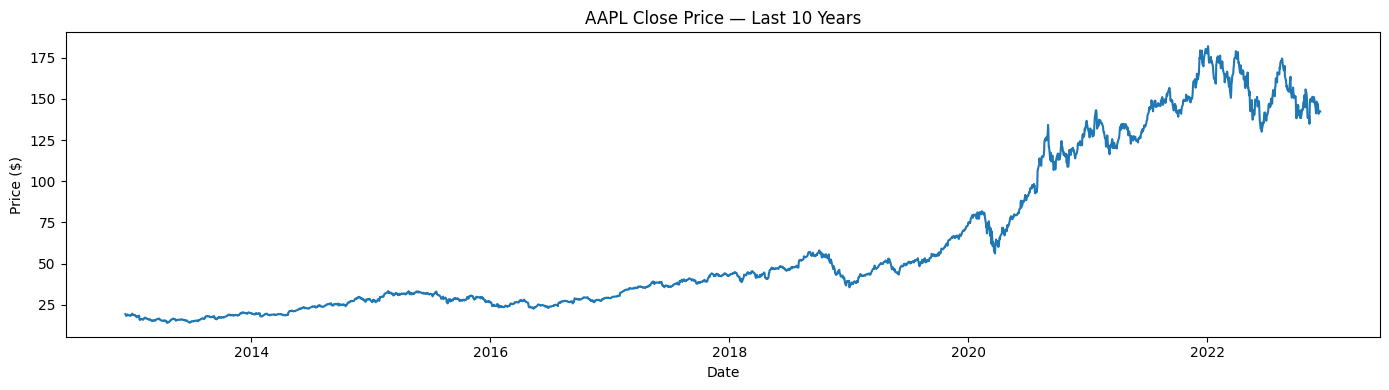

In [30]:
# ── Visualise price range ─────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(df_aapl['Date'], df_aapl['Close'])
plt.title('AAPL Close Price — Last 10 Years')
plt.xlabel('Date'); plt.ylabel('Price ($)')
plt.tight_layout(); plt.show()

## Helper: Window Builder & Normalisation
We define reusable functions used across all tasks.

In [68]:
# ════════════════════════════════════════════════════════════
# CORE HELPERS  (used by all three subtasks)
# ════════════════════════════════════════════════════════════

FEATURES    = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
CLOSE_COL   = 'Close'
WINDOW_SIZE = 30   # 30-day look-back


def chrono_split(X, y, val=0.10, test=0.10):
    """Strictly chronological train / val / test split."""
    n = len(X)
    n_te = int(n * test)
    n_vl = int(n * val)
    n_tr = n - n_vl - n_te
    return (X[:n_tr],          y[:n_tr],
            X[n_tr:n_tr+n_vl], y[n_tr:n_tr+n_vl],
            X[n_tr+n_vl:],     y[n_tr+n_vl:])


def build_windows(scaled_data, close_scaled, window_size,
                  forecast_offset=1, k_days=1):
    """
    Build sliding windows from ALREADY-SCALED data.

    scaled_data   : (T, n_features)  — all features, scaled
    close_scaled  : (T,)             — Close column only, scaled
    forecast_offset : predict the price N days ahead (Task 1.2)
    k_days          : predict K consecutive days    (Task 1.3)
    """
    X, y = [], []
    T = len(scaled_data)
    for i in range(T - window_size - forecast_offset - k_days + 2):
        X.append(scaled_data[i : i + window_size])
        y.append([
            close_scaled[i + window_size + forecast_offset - 1 + j]
            for j in range(k_days)
        ])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def scale_split(df, features=FEATURES, val=0.10, test=0.10):
    """
    Chronological split + fit MinMaxScaler on train only.
    Returns: full_scaled array, close_scaled 1-D, scaler, split sizes.
    """
    data  = df[features].values.astype(np.float32)
    n     = len(data)
    n_te  = int(n * test)
    n_vl  = int(n * val)
    n_tr  = n - n_vl - n_te

    scaler   = MinMaxScaler()
    scaler.fit(data[:n_tr])              # fit on training portion ONLY
    full_sc  = scaler.transform(data)    # transform all
    close_sc = full_sc[:, CLOSE_IDX]
    return full_sc, close_sc, scaler, n_tr, n_vl, n_te



def inverse_close(y_scaled, scaler, close_idx, n_features):
    """Inverse-transform a 1-D array of scaled Close values back to $."""
    dummy = np.zeros((len(y_scaled), n_features), dtype=np.float32)
    dummy[:, close_idx] = y_scaled.ravel()
    return scaler.inverse_transform(dummy)[:, close_idx]


def eval_metrics(y_true, y_pred, label=''):
    mse  = mean_squared_error(y_true.ravel(), y_pred.ravel())
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true.ravel(), y_pred.ravel())
    mape = np.mean(np.abs((y_true.ravel() - y_pred.ravel()) /
                           (np.abs(y_true.ravel()) + 1e-8))) * 100
    print(f'[{label}]  RMSE=${rmse:.3f}  MAE=${mae:.3f}  MAPE={mape:.2f}%')
    return rmse, mae, mape


def build_model(window_size, n_features, n_outputs=1):
    """CNN-LSTM model, same architecture for all subtasks."""
    model = Sequential([
        Conv1D(64, 3, activation='relu', padding='same',
               input_shape=(window_size, n_features)),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu', padding='same'),
        MaxPooling1D(2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(n_outputs)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-2),
                  loss='mse', metrics=['mae'])
    return model


CALLBACKS = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(patience=4, factor=0.5, verbose=0)
]

print('Helpers ready.')

Helpers ready.


## Task 1.1 — Multi-Feature Extension
We use all six features: Low, Open, Volume, High, Close, Adjusted Close.

In [69]:
# ── Scale data (fit scaler on train only) ─────────────────────
full_sc, close_sc, scaler_11, close_idx, n_tr, n_vl, n_te = \
    scale_split(df_aapl, FEATURES)

n_feat = full_sc.shape[1]

# ── Build windows ─────────────────────────────────────────────
X_all, y_all = build_windows(full_sc, close_sc,
                              WINDOW_SIZE, forecast_offset=1, k_days=1)

X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split(X_all, y_all)
print(f'Train {X_tr.shape[0]} | Val {X_vl.shape[0]} | Test {X_te.shape[0]}')

# ── Train ─────────────────────────────────────────────────────
model_11 = build_model(WINDOW_SIZE, n_feat, n_outputs=1)
history_11 = model_11.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=100, batch_size=64,
    callbacks=CALLBACKS, verbose=1
)

ValueError: not enough values to unpack (expected 7, got 6)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[Task 1.1 Test]  RMSE=$6.839  MAE=$5.686  MAPE=3.68%


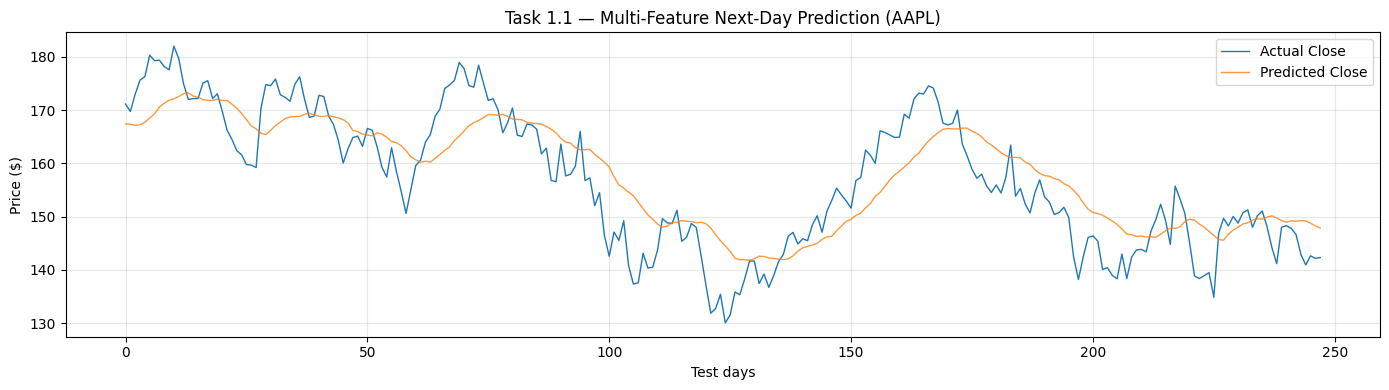

In [34]:
# ── Evaluate ──────────────────────────────────────────────────
y_pred_sc = model_11.predict(X_te).ravel()

# Inverse-transform both prediction and ground truth back to dollar prices
y_pred_11 = inverse_close(y_pred_sc,  scaler_11, close_idx, n_feat)
y_true_11 = inverse_close(y_te.ravel(), scaler_11, close_idx, n_feat)

eval_metrics(y_true_11, y_pred_11, 'Task 1.1 Test')

# ── Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(y_true_11, label='Actual Close', linewidth=1)
plt.plot(y_pred_11, label='Predicted Close', linewidth=1, alpha=0.8)
plt.title('Task 1.1 — Multi-Feature Next-Day Prediction (AAPL)')
plt.xlabel('Test days'); plt.ylabel('Price ($)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

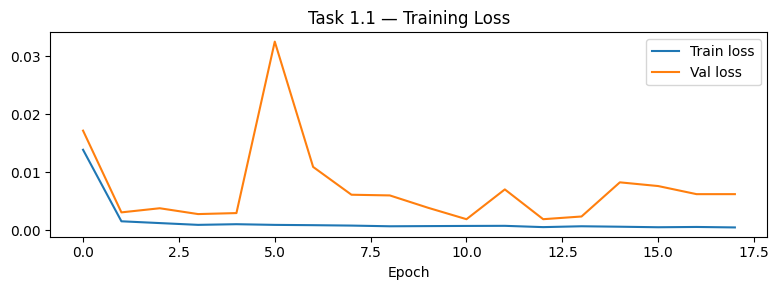

In [35]:
# ── Training loss curve ───────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(history_11.history['loss'],     label='Train loss')
plt.plot(history_11.history['val_loss'], label='Val loss')
plt.title('Task 1.1 — Training Loss'); plt.xlabel('Epoch')
plt.legend(); plt.tight_layout(); plt.show()

## Task 1.2 — N-th Day Forecast
Predict the price on the **N-th day** ahead (e.g., day 3, day 7) instead of the next day.

**Key change:** `forecast_offset=N` shifts the label window forward by N days.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[Task 1.2 (Day +7)]  RMSE=$10.270  MAE=$8.542  MAPE=5.50%


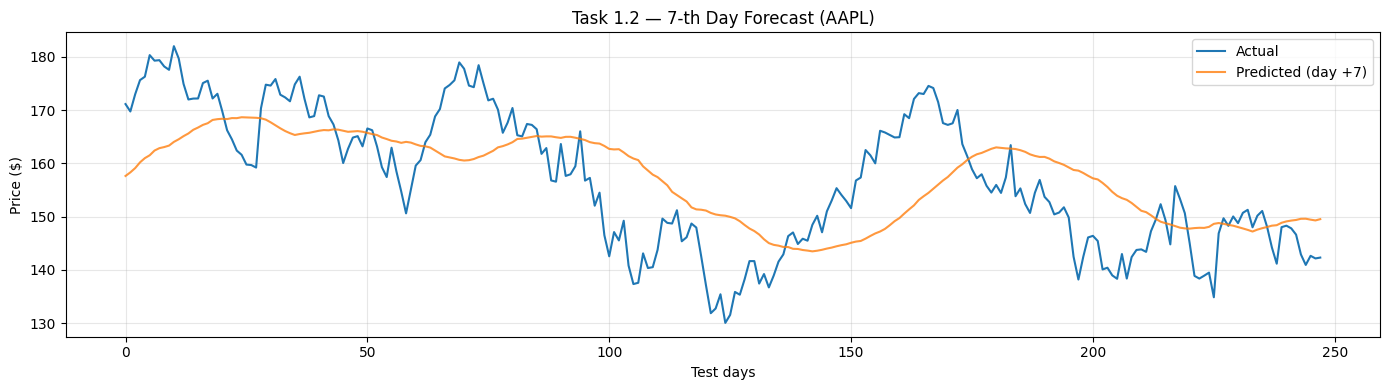

In [39]:
N_DAY = 7

X_all_12, y_all_12 = build_windows(full_sc, close_sc,
                                    WINDOW_SIZE,
                                    forecast_offset=N_DAY, k_days=1)

X_tr12, y_tr12, X_vl12, y_vl12, X_te12, y_te12 = chrono_split(X_all_12, y_all_12)

model_12 = build_model(WINDOW_SIZE, n_feat, n_outputs=1)
model_12.fit(X_tr12, y_tr12,
             validation_data=(X_vl12, y_vl12),
             epochs=100, batch_size=64,
             callbacks=CALLBACKS, verbose=0)

y_pred_12 = inverse_close(model_12.predict(X_te12).ravel(), scaler_11, close_idx, n_feat)
y_true_12 = inverse_close(y_te12.ravel(),                   scaler_11, close_idx, n_feat)

eval_metrics(y_true_12, y_pred_12, f'Task 1.2 (Day +{N_DAY})')

plt.figure(figsize=(14, 4))
plt.plot(y_true_12, label='Actual')
plt.plot(y_pred_12, label=f'Predicted (day +{N_DAY})', alpha=0.8)
plt.title(f'Task 1.2 — {N_DAY}-th Day Forecast (AAPL)')
plt.xlabel('Test days'); plt.ylabel('Price ($)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Task 1.3 — K Consecutive Days Forecast
Predict the next **K days** all at once by changing the output layer to `Dense(K)`.

In [46]:
K_DAYS = 7

X_all_13, y_all_13 = build_windows(full_sc, close_sc,
                                    WINDOW_SIZE,
                                    forecast_offset=1, k_days=K_DAYS)
print('y shape:', y_all_13.shape)   # (N, K_DAYS)

X_tr13, y_tr13, X_vl13, y_vl13, X_te13, y_te13 = chrono_split(X_all_13, y_all_13)

model_13 = build_model(WINDOW_SIZE, n_feat, n_outputs=K_DAYS)
model_13.fit(X_tr13, y_tr13,
             validation_data=(X_vl13, y_vl13),
             epochs=100, batch_size=32,
             callbacks=CALLBACKS, verbose=0)

y_pred_13_sc = model_13.predict(X_te13)   # shape (N, K_DAYS)

# Inverse-transform each horizon column separately
y_pred_13 = np.stack([
    inverse_close(y_pred_13_sc[:, d], scaler_11, close_idx, n_feat)
    for d in range(K_DAYS)
], axis=1)
y_true_13 = np.stack([
    inverse_close(y_te13[:, d], scaler_11, close_idx, n_feat)
    for d in range(K_DAYS)
], axis=1)

# Overall metric
eval_metrics(y_true_13, y_pred_13, f'Task 1.3 ({K_DAYS} days overall)')

# Per-horizon metrics
print('\nPer-horizon breakdown:')
for d in range(K_DAYS):
    eval_metrics(y_true_13[:, d], y_pred_13[:, d], f'  Day +{d+1}')

y shape: (2482, 7)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[Task 1.3 (7 days overall)]  RMSE=$15.129  MAE=$12.444  MAPE=7.64%

Per-horizon breakdown:
[  Day +1]  RMSE=$12.466  MAE=$10.115  MAPE=6.20%
[  Day +2]  RMSE=$17.658  MAE=$15.215  MAPE=9.33%
[  Day +3]  RMSE=$17.065  MAE=$14.636  MAPE=8.99%
[  Day +4]  RMSE=$13.209  MAE=$10.694  MAPE=6.56%
[  Day +5]  RMSE=$15.161  MAE=$12.504  MAPE=7.68%
[  Day +6]  RMSE=$16.736  MAE=$14.028  MAPE=8.60%
[  Day +7]  RMSE=$12.624  MAE=$9.919  MAPE=6.12%


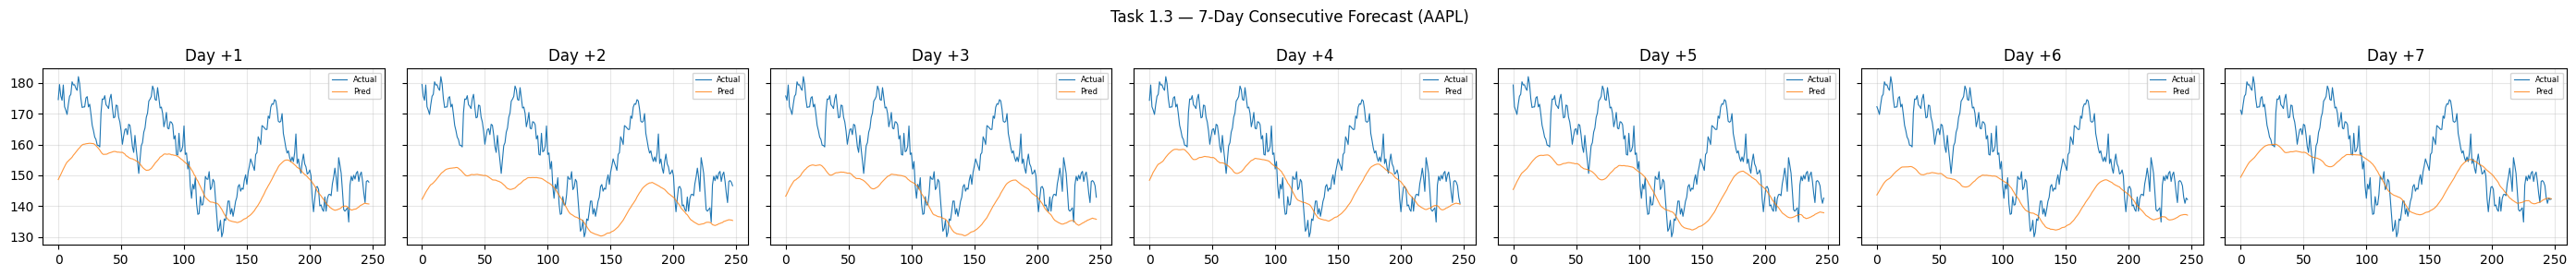

In [47]:
# ── Plot each horizon ─────────────────────────────────────────
fig, axes = plt.subplots(1, K_DAYS, figsize=(4 * K_DAYS, 3), sharey=True)
for d in range(K_DAYS):
    axes[d].plot(y_true_13[:, d], linewidth=0.8, label='Actual')
    axes[d].plot(y_pred_13[:, d], linewidth=0.8, label='Pred', alpha=0.8)
    axes[d].set_title(f'Day +{d+1}')
    axes[d].legend(fontsize=6)
    axes[d].grid(alpha=0.3)
fig.suptitle(f'Task 1.3 — {K_DAYS}-Day Consecutive Forecast (AAPL)')
plt.tight_layout(); plt.show()

## Task 1 — Cross-Validation with TimeSeriesSplit
We validate model stability using a rolling-window CV, respecting chronological order.

In [48]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_all)):
    Xf_tr, yf_tr = X_all[tr_idx], y_all[tr_idx]
    Xf_vl, yf_vl = X_all[vl_idx], y_all[vl_idx]

    m = build_model(WINDOW_SIZE, n_feat, 1)
    m.fit(Xf_tr, yf_tr, epochs=30, batch_size=32, verbose=0)

    yp_sc = m.predict(Xf_vl, verbose=0).ravel()
    yp    = inverse_close(yp_sc, scaler_11, close_idx, n_feat)
    yt    = inverse_close(yf_vl.ravel(), scaler_11, close_idx, n_feat)

    mape = np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-8))) * 100
    rmse = np.sqrt(mean_squared_error(yt, yp))
    cv_scores.append(mape)
    print(f'  Fold {fold+1}: RMSE=${rmse:.3f}  MAPE={mape:.2f}%')

print(f'\nCV MAPE: {np.mean(cv_scores):.2f}% ± {np.std(cv_scores):.2f}%')

  Fold 1: RMSE=$1.844  MAPE=5.35%
  Fold 2: RMSE=$3.009  MAPE=7.18%
  Fold 3: RMSE=$3.600  MAPE=7.12%
  Fold 4: RMSE=$15.761  MAPE=13.27%
  Fold 5: RMSE=$16.469  MAPE=10.11%

CV MAPE: 8.61% ± 2.79%


---
# TASK 2 — Vietnam Stock Price Prediction
---

Same three subtasks (2.1 multi-feature, 2.2 N-th day, 2.3 K days) applied to the Vietnam dataset.

In [49]:
# ── Paths — adjust to your Colab / Drive structure ────────────
BASE_PATH    = '/content/drive/MyDrive/DL4AI-project'   # <-- change this
HIST_PATH    = os.path.join(BASE_PATH, 'stock-historical-data')
OVERVIEW_CSV = os.path.join(BASE_PATH, 'ticker-overview.csv')
COMPANIES_CSV= os.path.join(BASE_PATH, 'companies.csv')

# ── Load overview ─────────────────────────────────────────────
df_overview = pd.read_csv(OVERVIEW_CSV)
print('Overview shape:', df_overview.shape)
print('Columns:', df_overview.columns.tolist())
df_overview.head(3)

Overview shape: (1629, 24)
Columns: ['Unnamed: 0', 'exchange', 'shortName', 'industryID', 'industryIDv2', 'industry', 'industryEn', 'establishedYear', 'noEmployees', 'noShareholders', 'foreignPercent', 'website', 'stockRating', 'deltaInWeek', 'deltaInMonth', 'deltaInYear', 'outstandingShare', 'issueShare', 'companyType', 'ticker', 'status', 'code', 'message', 'traceId']


,Unnamed: 0,exchange,shortName,industryID,industryIDv2,industry,industryEn,establishedYear,noEmployees,noShareholders,...,deltaInMonth,deltaInYear,outstandingShare,issueShare,companyType,ticker,status,code,message,traceId
0,0,UPCOM,Đầu tư Phát triển Máy Việt Nam,211.0,3353.0,Ô tô và phụ tùng,Automobiles & Parts,NaN,352.0,105.0,...,-0.098,NaN,20.5,20.5,CT,VVS,NaN,NaN,NaN,NaN
1,1,UPCOM,Xây dựng Công trình Tân Cảng,181.0,2357.0,Xây dựng và Vật liệu,Construction & Materials,NaN,110.0,0.0,...,-0.082,NaN,9.0,0.0,CT,XDC,NaN,NaN,NaN,NaN
2,2,UPCOM,Gang Thép Hà Nội,159.0,1757.0,Tài nguyên Cơ bản,Basic Resources,2013.0,0.0,109.0,...,0.064,-0.37,15.7,15.7,CT,HSV,NaN,NaN,NaN,NaN


In [50]:
# ── Show available industries so you can choose ───────────────
print('Industries available:')
print(df_overview['industryEn'].value_counts().to_string())

Industries available:
industryEn
Construction & Materials       337
Industrial Goods & Services    268
Food & Beverage                151
Utilities                      145
Real Estate                    126
Basic Resources                110
Personal & Household Goods      77
Chemicals                       73
Health Care                     59
Financial Services              55
Travel & Leisure                50
Media                           41
Retail                          32
Technology                      30
Banks                           27
Automobiles & Parts             15
Oil & Gas                       12
Insurance                       12
Telecommunications               8


In [51]:
# ── Choose your target sector ─────────────────────────────────
# Change TARGET_SECTOR to any industry shown above.
# Good choices with many companies: 'Banks', 'Real Estate', 'Steel'
TARGET_SECTOR = 'Insurance'   # <-- change if needed

sector_tickers = df_overview[
    df_overview['industryEn'].str.contains(TARGET_SECTOR, case=False, na=False)
]['ticker'].tolist()

print(f'Tickers in [{TARGET_SECTOR}]: {len(sector_tickers)}')
print(sector_tickers)

Tickers in [Insurance]: 12
['ABI', 'BIC', 'BLI', 'BMI', 'BVH', 'MIG', 'PGI', 'PTI', 'PVI', 'PRE', 'AIC', 'VNR']


In [52]:
MIN_ROWS = 2400   # ~10 years of trading days
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume']
DATE_COL = 'TradingDate'

def load_ticker(ticker, hist_path):
    """
    Find and load the CSV for a given ticker.
    Handles naming like VCB-VNINDEX-History.csv or VCB-HNXIndex-History.csv.
    """
    pattern = os.path.join(hist_path, f'{ticker}-*-History.csv')
    matches = glob.glob(pattern)
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    df.columns = [c.strip() for c in df.columns]
    if DATE_COL not in df.columns:
        return None
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df = df.dropna(subset=[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    missing_feats = [f for f in FEATURES if f not in df.columns]
    if missing_feats:
        return None
    df = df[[DATE_COL] + FEATURES].dropna()
    return df


# ── Load all sector tickers, keep those with enough history ───
vn_data = {}
for ticker in sector_tickers:
    df_t = load_ticker(ticker, HIST_PATH)
    if df_t is not None and len(df_t) >= MIN_ROWS:
        vn_data[ticker] = df_t
        print(f'  {ticker:8s}: {len(df_t)} rows  '
              f'({df_t[DATE_COL].min().date()} → {df_t[DATE_COL].max().date()})')

print(f'\nFinal selection: {len(vn_data)} companies')

  ABI     : 3329 rows  (2009-07-17 → 2023-02-28)
  BIC     : 2867 rows  (2011-09-06 → 2023-02-28)
  BMI     : 4041 rows  (2006-11-28 → 2023-02-28)
  BVH     : 3416 rows  (2009-06-25 → 2023-02-28)
  PGI     : 2893 rows  (2011-07-29 → 2023-02-28)
  PTI     : 2996 rows  (2011-03-02 → 2023-02-28)
  PVI     : 3880 rows  (2007-08-10 → 2023-02-28)
  VNR     : 4213 rows  (2006-03-13 → 2023-02-28)

Final selection: 8 companies


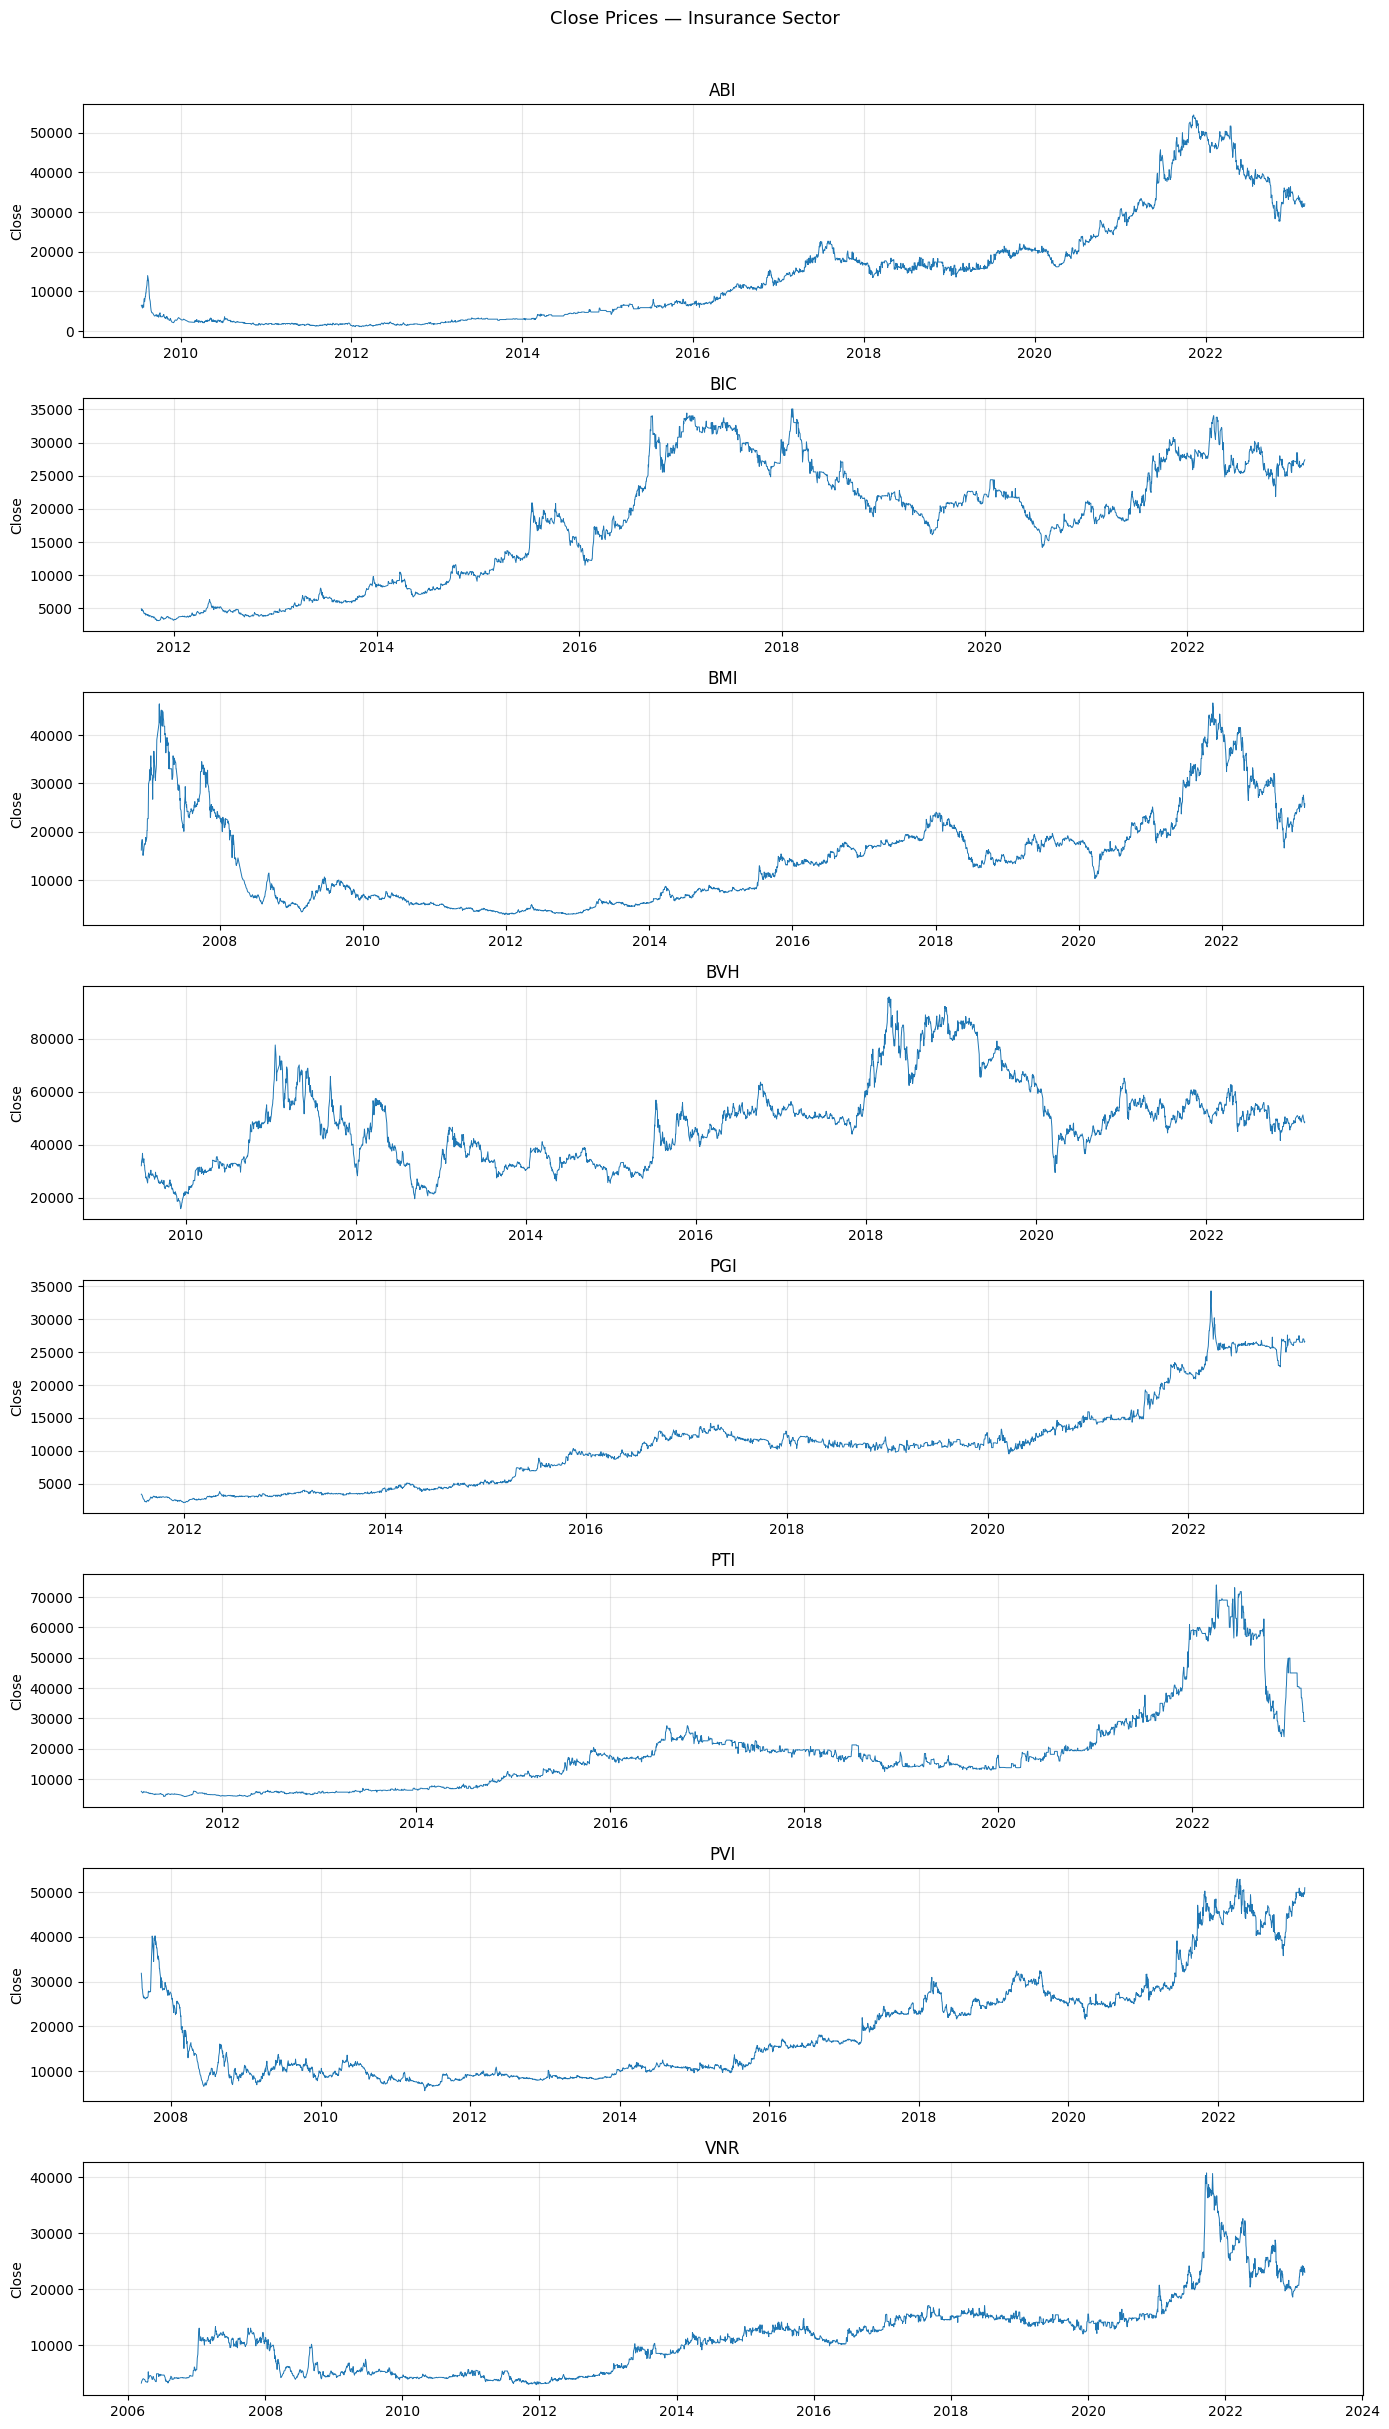

In [53]:
# ── Quick sanity check — plot Close prices for all tickers ────
fig, axes = plt.subplots(len(vn_data), 1,
                          figsize=(14, 3 * len(vn_data)),
                          sharex=False)
if len(vn_data) == 1:
    axes = [axes]

for ax, (ticker, df_t) in zip(axes, vn_data.items()):
    ax.plot(df_t[DATE_COL], df_t['Close'], linewidth=0.7)
    ax.set_title(ticker); ax.set_ylabel('Close')
    ax.grid(alpha=0.3)

plt.suptitle(f'Close Prices — {TARGET_SECTOR} Sector', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Task 2.1 — Vietnam Multi-Feature Extension

In [63]:
# override FEATURES from Task 1 which had 'Adjusted Close'
FEATURES  = ['Open', 'High', 'Low', 'Close', 'Volume']
CLOSE_IDX = FEATURES.index('Close')   # = 3
N_FEAT    = len(FEATURES)             # = 5
print('FEATURES confirmed:', FEATURES)

FEATURES confirmed: ['Open', 'High', 'Low', 'Close', 'Volume']


In [65]:
results_21 = {}   # store results for summary table
models_21  = {}   # store trained models (reused in CV)
scalers_21 = {}   # store scalers (reused in Tasks 3 & 4)

for ticker, df_t in vn_data.items():
    print(f'\n── {ticker} ──')

    # Scale
    full_sc, close_sc, scaler, n_tr, n_vl, n_te = scale_split(df_t, FEATURES)
    scalers_21[ticker] = scaler

    # Windows
    X_all, y_all = build_windows(full_sc, close_sc,
                                  WINDOW_SIZE, forecast_offset=1, k_days=1)
    X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split(X_all, y_all)
    print(f'  Train {X_tr.shape[0]} | Val {X_vl.shape[0]} | Test {X_te.shape[0]}')

    # Train
    m = build_model(WINDOW_SIZE, N_FEAT, n_outputs=1)
    m.fit(X_tr, y_tr,
          validation_data=(X_vl, y_vl),
          epochs=100, batch_size=32,
          callbacks=CALLBACKS, verbose=0)

    # Evaluate
    y_pred = inverse_close(m.predict(X_te, verbose=0), scaler, CLOSE_IDX, N_FEAT)
    y_true = inverse_close(y_te, scaler, CLOSE_IDX, N_FEAT)
    rmse, mae, mape = eval_metrics(y_true, y_pred, ticker)

    results_21[ticker] = dict(rmse=rmse, mae=mae, mape=mape,
                               y_true=y_true, y_pred=y_pred)
    models_21[ticker] = m

# ── Summary table ─────────────────────────────────────────────
df_res21 = pd.DataFrame([
    {'Ticker': t, 'RMSE': v['rmse'], 'MAE': v['mae'], 'MAPE (%)': v['mape']}
    for t, v in results_21.items()
])
df_res21.loc[len(df_res21)] = ['AVERAGE',
    df_res21['RMSE'].mean(),
    df_res21['MAE'].mean(),
    df_res21['MAPE (%)'].mean()]
print('\n=== Task 2.1 Summary ===')
print(df_res21.to_string(index=False))


── ABI ──
  Train 2641 | Val 329 | Test 329
[ABI]  RMSE=$7873.254  MAE=$6865.030  MAPE=15.65%

── BIC ──
  Train 2271 | Val 283 | Test 283
[BIC]  RMSE=$1614.457  MAE=$1184.547  MAPE=4.29%

── BMI ──
  Train 3209 | Val 401 | Test 401
[BMI]  RMSE=$1481.943  MAE=$1216.971  MAPE=3.85%

── BVH ──
  Train 2710 | Val 338 | Test 338
[BVH]  RMSE=$2945.670  MAE=$2109.514  MAPE=4.15%

── PGI ──
  Train 2291 | Val 286 | Test 286
[PGI]  RMSE=$5021.772  MAE=$4829.784  MAPE=18.61%

── PTI ──
  Train 2374 | Val 296 | Test 296
[PTI]  RMSE=$15600.330  MAE=$13565.537  MAPE=23.29%

── PVI ──
  Train 3080 | Val 385 | Test 385
[PVI]  RMSE=$7005.062  MAE=$6660.705  MAPE=14.69%

── VNR ──
  Train 3347 | Val 418 | Test 418
[VNR]  RMSE=$4645.907  MAE=$3726.285  MAPE=13.07%

=== Task 2.1 Summary ===
 Ticker         RMSE          MAE  MAPE (%)
    ABI  7873.253965  6865.029785 15.647735
    BIC  1614.457494  1184.547119  4.291364
    BMI  1481.942813  1216.970581  3.845099
    BVH  2945.670212  2109.513672  4.14

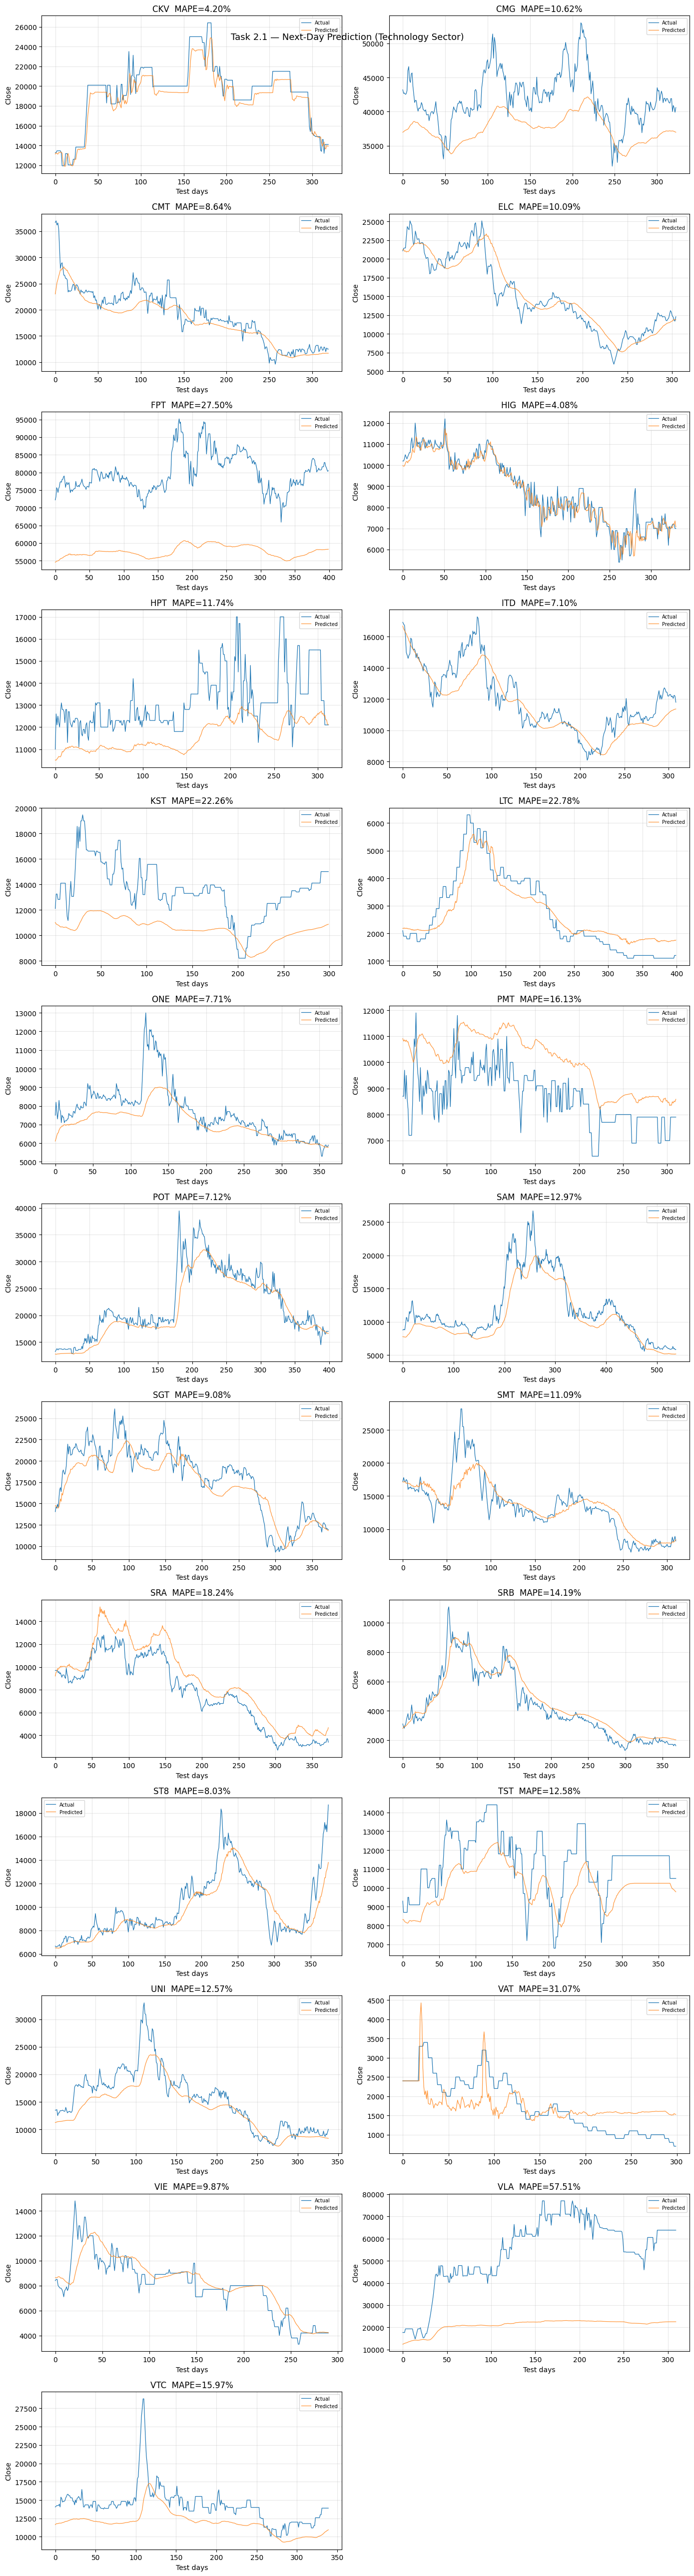

In [23]:
# ── Plot: Actual vs Predicted for each company ────────────────
n_cols = 2
n_rows = (len(vn_data) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(14, 4 * n_rows))
axes = axes.ravel()

for i, (ticker, res) in enumerate(results_21.items()):
    axes[i].plot(res['y_true'], label='Actual',    linewidth=0.9)
    axes[i].plot(res['y_pred'], label='Predicted', linewidth=0.9, alpha=0.8)
    axes[i].set_title(f'{ticker}  MAPE={res["mape"]:.2f}%')
    axes[i].set_xlabel('Test days'); axes[i].set_ylabel('Close')
    axes[i].legend(fontsize=7); axes[i].grid(alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Task 2.1 — Next-Day Prediction ({TARGET_SECTOR} Sector)',
             fontsize=13)
plt.tight_layout(); plt.show()

## Task 2.2 — Vietnam N-th Day Forecast

In [24]:
N_DAY = 7   # change to 3, 5, 10, etc.

results_22 = {}

for ticker, df_t in vn_data.items():
    print(f'\n── {ticker} (Day +{N_DAY}) ──')

    full_sc, close_sc, scaler, _, _, _ = scale_split(df_t)

    X_all, y_all = build_windows(full_sc, close_sc,
                                  WINDOW_SIZE,
                                  forecast_offset=N_DAY, k_days=1)
    X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split(X_all, y_all)

    m = build_model(WINDOW_SIZE, N_FEAT, n_outputs=1)
    m.fit(X_tr, y_tr,
          validation_data=(X_vl, y_vl),
          epochs=100, batch_size=32,
          callbacks=CALLBACKS, verbose=0)

    y_pred = inverse_close(m.predict(X_te, verbose=0), scaler)
    y_true = inverse_close(y_te, scaler)
    rmse, mae, mape = eval_metrics(y_true, y_pred, ticker)

    results_22[ticker] = dict(rmse=rmse, mae=mae, mape=mape,
                               y_true=y_true, y_pred=y_pred)

# ── Summary ───────────────────────────────────────────────────
df_res22 = pd.DataFrame([
    {'Ticker': t, 'RMSE': v['rmse'], 'MAE': v['mae'], 'MAPE (%)': v['mape']}
    for t, v in results_22.items()
])
df_res22.loc[len(df_res22)] = ['AVERAGE',
    df_res22['RMSE'].mean(), df_res22['MAE'].mean(), df_res22['MAPE (%)'].mean()]
print(f'\n=== Task 2.2 Summary (Day +{N_DAY}) ===')
print(df_res22.to_string(index=False))


── CKV (Day +7) ──
  [CKV]  RMSE=2576.584  MAE=1932.204  MAPE=9.72%

── CMG (Day +7) ──
  [CMG]  RMSE=9674.710  MAE=9081.021  MAPE=21.15%

── CMT (Day +7) ──
  [CMT]  RMSE=2650.479  MAE=1611.273  MAPE=8.49%

── ELC (Day +7) ──
  [ELC]  RMSE=2491.067  MAE=1969.184  MAPE=14.45%

── FPT (Day +7) ──
  [FPT]  RMSE=19475.400  MAE=18964.969  MAPE=23.56%

── HIG (Day +7) ──
  [HIG]  RMSE=748.822  MAE=591.588  MAPE=6.89%

── HPT (Day +7) ──
  [HPT]  RMSE=1785.154  MAE=1448.327  MAPE=10.50%

── ITD (Day +7) ──
  [ITD]  RMSE=1279.547  MAE=1060.068  MAPE=8.70%

── KST (Day +7) ──
  [KST]  RMSE=3188.545  MAE=2857.420  MAPE=20.33%

── LTC (Day +7) ──
  [LTC]  RMSE=1378.171  MAE=1182.863  MAPE=72.41%

── ONE (Day +7) ──
  [ONE]  RMSE=1155.242  MAE=750.011  MAPE=8.61%

── PMT (Day +7) ──
  [PMT]  RMSE=775.883  MAE=590.820  MAPE=7.02%

── POT (Day +7) ──
  [POT]  RMSE=3151.639  MAE=1853.394  MAPE=7.69%

── SAM (Day +7) ──
  [SAM]  RMSE=2605.750  MAE=1681.123  MAPE=12.47%

── SGT (Day +7) ──
  [SGT]  R

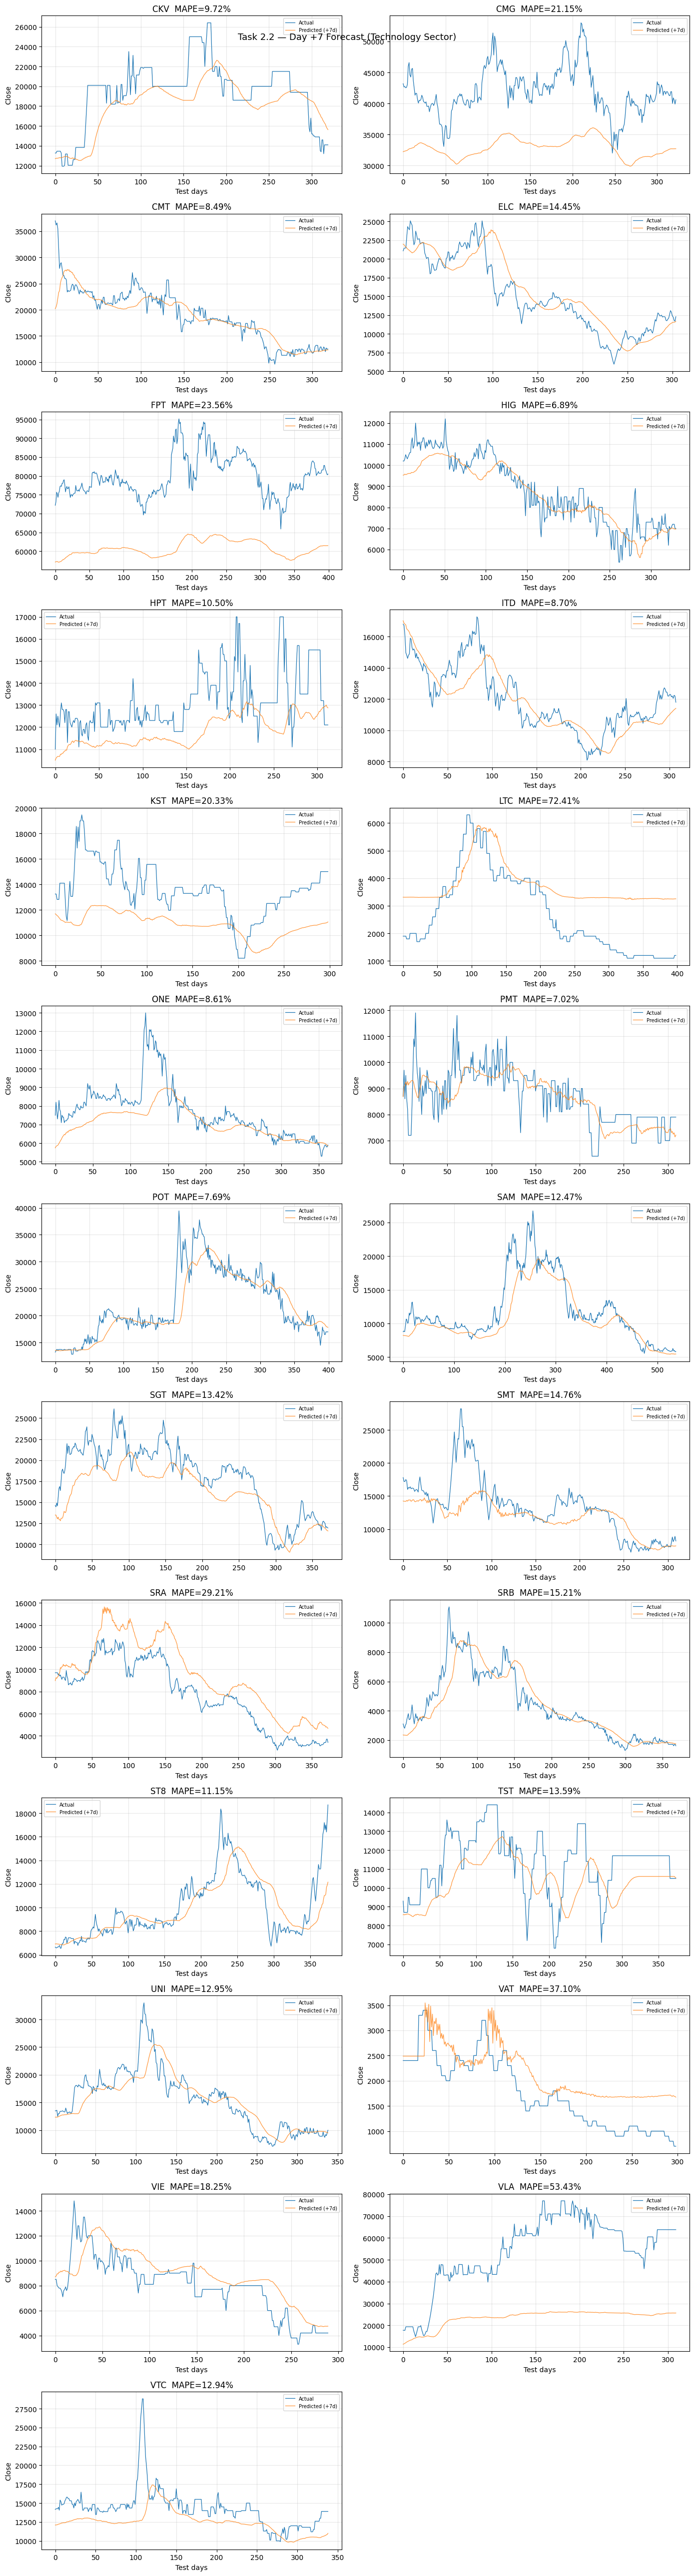

In [25]:
# ── Plot ──────────────────────────────────────────────────────
n_rows = (len(vn_data) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.ravel()

for i, (ticker, res) in enumerate(results_22.items()):
    axes[i].plot(res['y_true'], label='Actual',               linewidth=0.9)
    axes[i].plot(res['y_pred'], label=f'Predicted (+{N_DAY}d)', linewidth=0.9, alpha=0.8)
    axes[i].set_title(f'{ticker}  MAPE={res["mape"]:.2f}%')
    axes[i].set_xlabel('Test days'); axes[i].set_ylabel('Close')
    axes[i].legend(fontsize=7); axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Task 2.2 — Day +{N_DAY} Forecast ({TARGET_SECTOR} Sector)',
             fontsize=13)
plt.tight_layout(); plt.show()

## Task 2.3 — Vietnam K Consecutive Days Forecast

In [26]:
K_DAYS = 7   # change to 3, 5, etc.

results_23 = {}

for ticker, df_t in vn_data.items():
    print(f'\n── {ticker} ({K_DAYS} consecutive days) ──')

    full_sc, close_sc, scaler, _, _, _ = scale_split(df_t)

    X_all, y_all = build_windows(full_sc, close_sc,
                                  WINDOW_SIZE,
                                  forecast_offset=1, k_days=K_DAYS)
    X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split_xy(X_all, y_all)

    m = build_model(WINDOW_SIZE, N_FEAT, n_outputs=K_DAYS)
    m.fit(X_tr, y_tr,
          validation_data=(X_vl, y_vl),
          epochs=100, batch_size=32,
          callbacks=CALLBACKS, verbose=0)

    y_pred_sc = m.predict(X_te, verbose=0)   # (N, K_DAYS)

    # Inverse transform each horizon separately
    y_pred_k = np.stack(
        [inverse_close(y_pred_sc[:, d], scaler) for d in range(K_DAYS)], axis=1)
    y_true_k = np.stack(
        [inverse_close(y_te[:, d], scaler) for d in range(K_DAYS)], axis=1)

    # Overall metric
    rmse, mae, mape = eval_metrics(y_true_k, y_pred_k, f'{ticker} overall')

    # Per-horizon MAPE
    per_horizon_mape = [
        np.mean(np.abs((y_true_k[:, d] - y_pred_k[:, d]) /
                        (np.abs(y_true_k[:, d]) + 1e-8))) * 100
        for d in range(K_DAYS)
    ]
    print(f'  Per-horizon MAPE: ' +
          '  '.join([f'+{d+1}d:{v:.1f}%' for d, v in enumerate(per_horizon_mape)]))

    results_23[ticker] = dict(rmse=rmse, mae=mae, mape=mape,
                               y_true_k=y_true_k, y_pred_k=y_pred_k,
                               per_horizon_mape=per_horizon_mape)

# ── Summary ───────────────────────────────────────────────────
df_res23 = pd.DataFrame([
    {'Ticker': t, 'RMSE': v['rmse'], 'MAE': v['mae'], 'MAPE (%)': v['mape']}
    for t, v in results_23.items()
])
df_res23.loc[len(df_res23)] = ['AVERAGE',
    df_res23['RMSE'].mean(), df_res23['MAE'].mean(), df_res23['MAPE (%)'].mean()]
print(f'\n=== Task 2.3 Summary ({K_DAYS} consecutive days) ===')
print(df_res23.to_string(index=False))


── CKV (7 consecutive days) ──
  [CKV overall]  RMSE=2666.008  MAE=2086.202  MAPE=10.33%
  Per-horizon MAPE: +1d:13.1%  +2d:10.2%  +3d:9.0%  +4d:9.6%  +5d:9.5%  +6d:9.2%  +7d:11.5%

── CMG (7 consecutive days) ──
  [CMG overall]  RMSE=8375.121  MAE=7735.466  MAPE=17.95%
  Per-horizon MAPE: +1d:15.3%  +2d:18.1%  +3d:16.8%  +4d:21.2%  +5d:16.0%  +6d:19.2%  +7d:19.1%

── CMT (7 consecutive days) ──
  [CMT overall]  RMSE=2978.435  MAE=1836.856  MAPE=9.04%
  Per-horizon MAPE: +1d:8.3%  +2d:9.0%  +3d:9.4%  +4d:9.4%  +5d:8.8%  +6d:9.2%  +7d:9.2%

── ELC (7 consecutive days) ──
  [ELC overall]  RMSE=2093.017  MAE=1642.542  MAPE=12.19%
  Per-horizon MAPE: +1d:10.2%  +2d:11.2%  +3d:10.6%  +4d:12.2%  +5d:13.0%  +6d:14.4%  +7d:13.8%

── FPT (7 consecutive days) ──
  [FPT overall]  RMSE=29034.186  MAE=28626.043  MAPE=35.73%
  Per-horizon MAPE: +1d:37.3%  +2d:36.6%  +3d:35.0%  +4d:37.1%  +5d:35.5%  +6d:33.6%  +7d:34.9%

── HIG (7 consecutive days) ──
  [HIG overall]  RMSE=651.575  MAE=512.167  MAPE

---
# TASK 3 — Trading Signal Identification (Vietnam)
---

**Approach:**
- Frame as a **binary classification** problem.
- **Buy signal:** price rises ≥ `BUY_THRESHOLD` % within the next `HORIZON` trading days.
- **Sell signal:** price falls ≥ `SELL_THRESHOLD` % within the next `HORIZON` trading days.
- **Features:** raw OHLCV + manually engineered indicators (SMA, RSI, MACD, Bollinger Bands).
- **Model:** CNN-LSTM binary classifier.

In [27]:
# ── Technical indicator helpers ───────────────────────────────
def compute_sma(series, window):
    return series.rolling(window).mean()

def compute_ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-8)
    return 100 - 100 / (1 + rs)

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_f = compute_ema(series, fast)
    ema_s = compute_ema(series, slow)
    macd  = ema_f - ema_s
    sig   = compute_ema(macd, signal)
    hist  = macd - sig
    return macd, sig, hist

def compute_bollinger(series, window=20, n_std=2):
    sma  = series.rolling(window).mean()
    std  = series.rolling(window).std()
    upper = sma + n_std * std
    lower = sma - n_std * std
    return upper, sma, lower


def build_features(df):
    """Add technical indicators to a OHLCV DataFrame."""
    d = df.copy()
    close = d['Close']
    volume = d['Volume']

    d['SMA5']   = compute_sma(close, 5)
    d['SMA20']  = compute_sma(close, 20)
    d['SMA60']  = compute_sma(close, 60)
    d['EMA12']  = compute_ema(close, 12)
    d['EMA26']  = compute_ema(close, 26)
    d['RSI14']  = compute_rsi(close, 14)

    macd, macd_sig, macd_hist = compute_macd(close)
    d['MACD']     = macd
    d['MACDsig']  = macd_sig
    d['MACDhist'] = macd_hist

    bb_up, bb_mid, bb_low = compute_bollinger(close)
    d['BB_upper'] = bb_up
    d['BB_mid']   = bb_mid
    d['BB_lower'] = bb_low
    d['BB_width'] = (bb_up - bb_low) / (bb_mid + 1e-8)

    d['Vol_change'] = volume.pct_change()
    d['Return1']    = close.pct_change(1)
    d['Return5']    = close.pct_change(5)

    return d.dropna().reset_index(drop=True)


def make_labels(df, horizon=5, buy_thr=0.02, sell_thr=0.02):
    """
    Create binary buy/sell labels.
    Buy  label = 1 if max return in next `horizon` days >= buy_thr
    Sell label = 1 if min return in next `horizon` days <= -sell_thr
    """
    close = df['Close'].values
    n = len(close)
    buy_labels  = np.zeros(n, dtype=int)
    sell_labels = np.zeros(n, dtype=int)
    for i in range(n - horizon):
        future = close[i+1 : i+1+horizon]
        max_ret = (future.max() - close[i]) / (close[i] + 1e-8)
        min_ret = (future.min() - close[i]) / (close[i] + 1e-8)
        if max_ret >= buy_thr:
            buy_labels[i] = 1
        if min_ret <= -sell_thr:
            sell_labels[i] = 1
    # remove last `horizon` rows (no future data)
    return buy_labels[:-horizon], sell_labels[:-horizon]

print('Technical indicator helpers defined.')

Technical indicator helpers defined.


In [28]:
# ── Build feature matrix for demo ticker ─────────────────────
HORIZON    = 5     # look 5 days ahead
BUY_THR    = 0.02  # 2% gain threshold for buy
SELL_THR   = 0.02  # 2% drop threshold for sell
WIN_CLS    = 30    # classification window size

df_feat = build_features(df_vn)
feat_cols = [c for c in df_feat.columns if c not in ['Date']]
print(f'Feature columns ({len(feat_cols)}): {feat_cols}')

buy_lbl, sell_lbl = make_labels(df_feat, HORIZON, BUY_THR, SELL_THR)
feat_np = df_feat[feat_cols].values[:len(buy_lbl)]   # align lengths

print(f'Samples: {len(feat_np)}')
print(f'Buy  positives: {buy_lbl.sum()} ({100*buy_lbl.mean():.1f}%)')
print(f'Sell positives: {sell_lbl.sum()} ({100*sell_lbl.mean():.1f}%)')

NameError: name 'df_vn' is not defined

In [ ]:
# ── Build classification windows ─────────────────────────────
def make_cls_windows(features, labels, win):
    X, y = [], []
    for i in range(len(features) - win):
        X.append(features[i:i+win])
        y.append(labels[i+win])      # label at the END of the window
    return np.array(X, dtype=float), np.array(y, dtype=int)


def build_cls_model(window_size, n_features):
    model = Sequential([
        Conv1D(64, 3, activation='relu',
               input_shape=(window_size, n_features), padding='same'),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu', padding='same'),
        MaxPooling1D(2),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


def train_eval_classifier(X_all, y_all, label='Signal',
                           val_ratio=0.1, test_ratio=0.1):
    n = len(X_all)
    n_test  = int(n * test_ratio)
    n_val   = int(n * val_ratio)
    n_train = n - n_val - n_test

    X_tr, y_tr = X_all[:n_train], y_all[:n_train]
    X_vl, y_vl = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
    X_te, y_te = X_all[n_train+n_val:], y_all[n_train+n_val:]

    # Normalise with global scaler (classification needs consistent scale)
    scaler = MinMaxScaler()
    shape_tr = X_tr.shape
    X_tr_n = scaler.fit_transform(X_tr.reshape(-1, X_tr.shape[-1])).reshape(shape_tr)
    X_vl_n = scaler.transform(X_vl.reshape(-1, X_vl.shape[-1])).reshape(X_vl.shape)
    X_te_n = scaler.transform(X_te.reshape(-1, X_te.shape[-1])).reshape(X_te.shape)

    # Class weights to handle imbalance
    pos = y_tr.sum(); neg = len(y_tr) - pos
    class_w = {0: 1.0, 1: neg / (pos + 1e-8)}

    model = build_cls_model(X_tr_n.shape[1], X_tr_n.shape[2])
    cb = [EarlyStopping(patience=5, restore_best_weights=True)]
    model.fit(X_tr_n, y_tr,
              validation_data=(X_vl_n, y_vl),
              epochs=50, batch_size=64,
              class_weight=class_w,
              callbacks=cb, verbose=0)

    y_prob = model.predict(X_te_n).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f'\n=== {label} — Test Set ===')
    print(classification_report(y_te, y_pred, target_names=['No signal', 'Signal']))

    return model, scaler, y_prob, y_te

print('Classification helpers defined.')

## Task 3.1 — Buying Signal Identification

In [ ]:
X_buy, y_buy = make_cls_windows(feat_np, buy_lbl, WIN_CLS)
print('Buy windows:', X_buy.shape, '| Positives:', y_buy.sum())

model_buy, scaler_buy, buy_probs, buy_true = train_eval_classifier(
    X_buy, y_buy, label='BUY Signal'
)

In [ ]:
# ── Visualise buy signal probability on test set ─────────────
plt.figure(figsize=(14, 4))
plt.plot(buy_probs, label='Buy probability', color='green', alpha=0.7)
plt.axhline(0.5, color='red', linestyle='--', label='Threshold 0.5')
plt.scatter(np.where(buy_true == 1)[0], buy_probs[buy_true == 1],
            color='green', s=10, label='True buy')
plt.title('Task 3.1 — Buy Signal Probability (test set)')
plt.xlabel('Days'); plt.ylabel('Probability')
plt.legend(); plt.tight_layout(); plt.show()

## Task 3.2 — Selling Signal Identification

In [ ]:
X_sell, y_sell = make_cls_windows(feat_np, sell_lbl, WIN_CLS)
print('Sell windows:', X_sell.shape, '| Positives:', y_sell.sum())

model_sell, scaler_sell, sell_probs, sell_true = train_eval_classifier(
    X_sell, y_sell, label='SELL Signal'
)

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(sell_probs, label='Sell probability', color='red', alpha=0.7)
plt.axhline(0.5, color='black', linestyle='--', label='Threshold 0.5')
plt.scatter(np.where(sell_true == 1)[0], sell_probs[sell_true == 1],
            color='red', s=10, label='True sell')
plt.title('Task 3.2 — Sell Signal Probability (test set)')
plt.xlabel('Days'); plt.ylabel('Probability')
plt.legend(); plt.tight_layout(); plt.show()

---
# TASK 4 — Portfolio Composition, Risk Management & Optimization
---

**Pipeline:**
1. **Task 4.1** — Score each company's profitability using predicted returns + financial ratios.
2. **Task 4.2** — Score each company's risk using volatility, max drawdown, Sharpe ratio, and financial health.
3. **Task 4.3** — Combine scores to build optimal portfolios for risk-takers and prudent investors using mean-variance optimisation.

## Task 4 — Compute Per-Company Metrics

In [ ]:
# ── Risk & return helpers ─────────────────────────────────────
def compute_annualised_return(prices, trading_days=252):
    """Compound annualised growth rate."""
    if len(prices) < 2:
        return np.nan
    total_return = (prices[-1] / prices[0]) - 1
    years = len(prices) / trading_days
    return (1 + total_return) ** (1 / years) - 1 if years > 0 else np.nan


def compute_annualised_volatility(prices, trading_days=252):
    """Annualised std of daily log-returns."""
    lr = np.diff(np.log(prices + 1e-8))
    return np.std(lr) * np.sqrt(trading_days)


def compute_max_drawdown(prices):
    """Maximum peak-to-trough drawdown."""
    peak = prices[0]
    max_dd = 0.0
    for p in prices:
        if p > peak:
            peak = p
        dd = (peak - p) / (peak + 1e-8)
        if dd > max_dd:
            max_dd = dd
    return max_dd


def compute_sharpe(prices, risk_free=0.04, trading_days=252):
    """Annualised Sharpe ratio (assuming a 4% risk-free rate)."""
    lr = np.diff(np.log(prices + 1e-8))
    mean_lr = np.mean(lr) * trading_days
    std_lr  = np.std(lr)  * np.sqrt(trading_days)
    return (mean_lr - risk_free) / (std_lr + 1e-8)


print('Risk/return helpers defined.')

In [ ]:
# ── Compute fundamental metrics for every VN ticker ───────────
# We split each ticker: 80% 'history' for scoring, 20% 'future' for validation
SCORE_SPLIT = 0.8

metrics_rows = []
for ticker, df_t in vn_clean.items():
    prices = df_t['Close'].values
    split  = int(len(prices) * SCORE_SPLIT)
    hist   = prices[:split]
    future = prices[split:]

    ann_ret  = compute_annualised_return(hist)
    ann_vol  = compute_annualised_volatility(hist)
    max_dd   = compute_max_drawdown(hist)
    sharpe   = compute_sharpe(hist)

    # Projected future return (ground truth for validation)
    if len(future) > 0:
        future_ret = (future[-1] - hist[-1]) / (hist[-1] + 1e-8)
    else:
        future_ret = np.nan

    metrics_rows.append({
        'ticker':      ticker,
        'ann_return':  ann_ret,
        'ann_vol':     ann_vol,
        'max_drawdown':max_dd,
        'sharpe':      sharpe,
        'future_ret':  future_ret,
        'n_rows':      len(prices)
    })

df_metrics = pd.DataFrame(metrics_rows).dropna()
print(f'Metrics computed for {len(df_metrics)} tickers')
df_metrics.sort_values('sharpe', ascending=False).head(10)

In [ ]:
# ── (Optional) Merge financial ratio data ─────────────────────
FIN_RATIO_PATH = './financial-ratio'

fin_files = glob.glob(os.path.join(FIN_RATIO_PATH, '*.csv'))
if fin_files:
    fin_dfs = []
    for f in fin_files:
        try:
            fdf = pd.read_csv(f)
            fdf.columns = [c.strip().lower() for c in fdf.columns]
            fin_dfs.append(fdf)
        except Exception:
            pass
    if fin_dfs:
        df_fin = pd.concat(fin_dfs, ignore_index=True)
        print('Financial ratio columns:', df_fin.columns.tolist())
        # Example merge — adjust column names to match your actual data
        # df_metrics = df_metrics.merge(df_fin[['ticker','roe','pe','debt_equity']],
        #                               on='ticker', how='left')
        print('Financial data loaded — merge manually after inspecting columns above.')
else:
    print('No financial ratio files found. Proceeding without them.')

## Task 4.1 — Profitable Stock Selection

**Methodology:** We score profitability as a weighted combination of
- Annualised historical return (50%)
- Sharpe ratio (30%)
- Projected future return from Task 2 model (20%)

All components are ranked and normalised [0, 1] before combining.

In [ ]:
# ── Rank-normalise helper ─────────────────────────────────────
def rank_norm(series):
    """Rank and scale to [0, 1]. Higher is better."""
    ranks = series.rank(method='average', ascending=True)
    return (ranks - 1) / (len(ranks) - 1)


# ── Profitability score ───────────────────────────────────────
df_scores = df_metrics.copy()

df_scores['ret_score']    = rank_norm(df_scores['ann_return'])
df_scores['sharpe_score'] = rank_norm(df_scores['sharpe'])
df_scores['fut_score']    = rank_norm(df_scores['future_ret'])

df_scores['profit_score'] = (
    0.50 * df_scores['ret_score'] +
    0.30 * df_scores['sharpe_score'] +
    0.20 * df_scores['fut_score']
)

df_scores = df_scores.sort_values('profit_score', ascending=False)
TOP_N = 20
top_tickers = df_scores.head(TOP_N)['ticker'].tolist()

print(f'Top {TOP_N} profitable stocks:')
df_scores[['ticker', 'ann_return', 'sharpe', 'future_ret', 'profit_score']].head(TOP_N)

In [ ]:
# ── Visualise top 20 profit scores ───────────────────────────
top20 = df_scores.head(TOP_N)
plt.figure(figsize=(12, 5))
plt.barh(top20['ticker'][::-1], top20['profit_score'][::-1], color='steelblue')
plt.xlabel('Profitability Score (0–1)')
plt.title(f'Task 4.1 — Top {TOP_N} Profitable Stocks')
plt.tight_layout(); plt.show()

## Task 4.2 — Risk Management

**Methodology:** Risk score is a weighted combination of
- Annualised volatility (40%) — higher vol → higher risk
- Maximum drawdown (40%) — larger drawdown → higher risk
- Sharpe ratio (20%, inverse) — lower Sharpe → higher risk

High-risk companies (risk_score > threshold) are flagged for exclusion.

In [ ]:
# ── Risk score (higher = riskier) ────────────────────────────
df_scores['vol_score']    = rank_norm(df_scores['ann_vol'])      # high vol = high risk
df_scores['dd_score']     = rank_norm(df_scores['max_drawdown']) # high DD  = high risk
df_scores['inv_sharpe']   = rank_norm(-df_scores['sharpe'])      # low Sharpe = high risk

df_scores['risk_score'] = (
    0.40 * df_scores['vol_score'] +
    0.40 * df_scores['dd_score'] +
    0.20 * df_scores['inv_sharpe']
)

RISK_THRESHOLD = 0.70   # companies above this are excluded from prudent portfolio
df_scores['high_risk'] = df_scores['risk_score'] > RISK_THRESHOLD

print('High-risk companies (excluded from prudent portfolio):')
print(df_scores[df_scores['high_risk']]['ticker'].tolist())

# Sort by risk
df_scores.sort_values('risk_score', ascending=False)[
    ['ticker', 'ann_vol', 'max_drawdown', 'sharpe', 'risk_score', 'high_risk']
].head(15)

In [ ]:
# ── Risk vs. Return scatter ───────────────────────────────────
plt.figure(figsize=(10, 6))
colors = df_scores['high_risk'].map({True: 'red', False: 'steelblue'})
plt.scatter(df_scores['ann_vol'], df_scores['ann_return'],
            c=colors, alpha=0.7, s=40)
plt.axvline(df_scores['ann_vol'].median(), color='grey',
            linestyle='--', label='Median vol')
plt.xlabel('Annualised Volatility'); plt.ylabel('Annualised Return')
plt.title('Task 4.2 — Risk vs. Return (red = high risk)')
plt.legend(['High risk', 'Low risk', 'Median vol'])
plt.tight_layout(); plt.show()

## Task 4.3 — Portfolio Composition (Mean-Variance Optimisation)

**Methodology:**
- We build **two portfolios** from the top profitable & low-risk companies:
  1. **Prudent portfolio** — minimise volatility subject to a minimum return target.
  2. **Aggressive portfolio** — maximise Sharpe ratio (risk-takers).
- Optimisation is done via `scipy.optimize` (no external portfolio library needed).
- Daily return correlations and covariances are estimated from historical Close prices.

In [ ]:
from scipy.optimize import minimize

# ── Select candidate tickers for portfolio ────────────────────
# Prudent: top profitable AND low risk
prudent_pool = df_scores[
    (df_scores['profit_score'] >= df_scores['profit_score'].quantile(0.60)) &
    (~df_scores['high_risk'])
]['ticker'].tolist()

# Aggressive: top profitable (risk ignored)
aggressive_pool = df_scores.nlargest(TOP_N, 'profit_score')['ticker'].tolist()

print(f'Prudent pool   : {len(prudent_pool)} tickers')
print(f'Aggressive pool: {len(aggressive_pool)} tickers')

In [ ]:
# ── Build returns matrix ──────────────────────────────────────
def get_returns_matrix(tickers, dfs, min_overlap=120):
    """Return a DataFrame of daily log-returns, aligned by date."""
    price_dict = {}
    for t in tickers:
        if t in dfs:
            df_t = dfs[t].set_index('Date')['Close']
            price_dict[t] = df_t
    prices = pd.DataFrame(price_dict).dropna(axis=0, how='any')
    if len(prices) < min_overlap:
        return None
    returns = np.log(prices / prices.shift(1)).dropna()
    return returns


def portfolio_stats(weights, mu, cov, trading_days=252, risk_free=0.04):
    port_return = np.dot(weights, mu) * trading_days
    port_vol    = np.sqrt(weights @ cov @ weights) * np.sqrt(trading_days)
    sharpe      = (port_return - risk_free) / (port_vol + 1e-8)
    return port_return, port_vol, sharpe


def optimise_portfolio(returns_df, strategy='max_sharpe', risk_free=0.04):
    """
    strategy: 'max_sharpe' or 'min_vol'
    Returns optimal weights dict.
    """
    mu  = returns_df.mean().values
    cov = returns_df.cov().values
    n   = len(mu)

    # Constraints: weights sum to 1; each weight in [0, 1]
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = tuple((0.0, 1.0) for _ in range(n))
    init_w = np.ones(n) / n

    if strategy == 'max_sharpe':
        def neg_sharpe(w):
            _, _, sr = portfolio_stats(w, mu, cov, risk_free=risk_free)
            return -sr
        result = minimize(neg_sharpe, init_w,
                          method='SLSQP', bounds=bounds,
                          constraints=constraints,
                          options={'maxiter': 1000})
    else:  # min_vol
        def port_vol(w):
            return np.sqrt(w @ cov @ w) * np.sqrt(252)
        result = minimize(port_vol, init_w,
                          method='SLSQP', bounds=bounds,
                          constraints=constraints,
                          options={'maxiter': 1000})

    if not result.success:
        print('Optimisation warning:', result.message)

    weights = result.x
    weights[weights < 0.01] = 0    # drop tiny allocations
    weights /= weights.sum()       # renormalise

    ret, vol, sr = portfolio_stats(weights, mu, cov, risk_free=risk_free)
    return dict(zip(returns_df.columns, weights)), ret, vol, sr


print('Portfolio optimisation helpers defined.')

In [ ]:
# ── Prudent portfolio — Minimum Volatility ────────────────────
ret_prudent = get_returns_matrix(prudent_pool, vn_clean)

if ret_prudent is not None and len(ret_prudent.columns) >= 2:
    w_pru, r_pru, v_pru, s_pru = optimise_portfolio(ret_prudent, strategy='min_vol')

    w_pru_clean = {t: w for t, w in w_pru.items() if w > 0.005}
    print('=== Prudent Portfolio (Min Volatility) ===')
    for t, w in sorted(w_pru_clean.items(), key=lambda x: -x[1]):
        print(f'  {t:8s}: {w*100:.1f}%')
    print(f'  Annual Return : {r_pru*100:.2f}%')
    print(f'  Annual Volatility: {v_pru*100:.2f}%')
    print(f'  Sharpe Ratio  : {s_pru:.3f}')
else:
    print('Not enough prudent tickers with overlapping dates.')
    w_pru_clean = {}

In [ ]:
# ── Aggressive portfolio — Maximum Sharpe ─────────────────────
ret_aggr = get_returns_matrix(aggressive_pool, vn_clean)

if ret_aggr is not None and len(ret_aggr.columns) >= 2:
    w_aggr, r_aggr, v_aggr, s_aggr = optimise_portfolio(ret_aggr, strategy='max_sharpe')

    w_aggr_clean = {t: w for t, w in w_aggr.items() if w > 0.005}
    print('=== Aggressive Portfolio (Max Sharpe) ===')
    for t, w in sorted(w_aggr_clean.items(), key=lambda x: -x[1]):
        print(f'  {t:8s}: {w*100:.1f}%')
    print(f'  Annual Return : {r_aggr*100:.2f}%')
    print(f'  Annual Volatility: {v_aggr*100:.2f}%')
    print(f'  Sharpe Ratio  : {s_aggr:.3f}')
else:
    print('Not enough aggressive tickers with overlapping dates.')
    w_aggr_clean = {}

In [ ]:
# ── Portfolio allocation pie charts ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if w_pru_clean:
    axes[0].pie(list(w_pru_clean.values()),
                labels=list(w_pru_clean.keys()),
                autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Prudent Portfolio (Min Volatility)')
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center')

if w_aggr_clean:
    axes[1].pie(list(w_aggr_clean.values()),
                labels=list(w_aggr_clean.keys()),
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Aggressive Portfolio (Max Sharpe)')
else:
    axes[1].text(0.5, 0.5, 'No data', ha='center')

plt.suptitle('Task 4.3 — Portfolio Composition')
plt.tight_layout(); plt.show()

In [ ]:
# ── Efficient Frontier — Monte Carlo simulation ───────────────
# Use whichever return matrix is available
ret_mc = ret_aggr if ret_aggr is not None else ret_prudent

if ret_mc is not None and len(ret_mc.columns) >= 2:
    mu_mc  = ret_mc.mean().values
    cov_mc = ret_mc.cov().values
    n_mc   = len(mu_mc)

    N_SIM = 5000
    sim_returns, sim_vols, sim_sharpes = [], [], []
    np.random.seed(42)
    for _ in range(N_SIM):
        w = np.random.dirichlet(np.ones(n_mc))
        r, v, s = portfolio_stats(w, mu_mc, cov_mc)
        sim_returns.append(r); sim_vols.append(v); sim_sharpes.append(s)

    sim_returns  = np.array(sim_returns)
    sim_vols     = np.array(sim_vols)
    sim_sharpes  = np.array(sim_sharpes)

    plt.figure(figsize=(10, 6))
    sc = plt.scatter(sim_vols, sim_returns, c=sim_sharpes,
                     cmap='viridis', alpha=0.4, s=10)
    plt.colorbar(sc, label='Sharpe Ratio')

    if w_pru_clean:
        plt.scatter([v_pru], [r_pru], marker='*', s=300, color='blue',
                    zorder=5, label=f'Prudent  (S={s_pru:.2f})')
    if w_aggr_clean:
        plt.scatter([v_aggr], [r_aggr], marker='*', s=300, color='red',
                    zorder=5, label=f'Aggressive (S={s_aggr:.2f})')

    plt.xlabel('Annual Volatility'); plt.ylabel('Annual Return')
    plt.title('Task 4.3 — Efficient Frontier')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print('Not enough data for efficient frontier.')

In [ ]:
# ── Summary comparison table ──────────────────────────────────
summary = []
if w_pru_clean:
    summary.append({'Portfolio': 'Prudent (Min Vol)',
                    'Tickers': ', '.join(list(w_pru_clean.keys())[:5]) + '...',
                    'Ann. Return (%)': round(r_pru * 100, 2),
                    'Ann. Vol (%)':    round(v_pru * 100, 2),
                    'Sharpe':          round(s_pru, 3)})
if w_aggr_clean:
    summary.append({'Portfolio': 'Aggressive (Max Sharpe)',
                    'Tickers': ', '.join(list(w_aggr_clean.keys())[:5]) + '...',
                    'Ann. Return (%)': round(r_aggr * 100, 2),
                    'Ann. Vol (%)':    round(v_aggr * 100, 2),
                    'Sharpe':          round(s_aggr, 3)})

if summary:
    pd.DataFrame(summary).set_index('Portfolio')
else:
    print('No portfolio results to display.')

---
## Summary

| Task | Description | Status |
|------|-------------|--------|
| 1.1  | Nasdaq multi-feature extension | ✅ |
| 1.2  | Nasdaq N-th day forecast | ✅ |
| 1.3  | Nasdaq K consecutive days forecast | ✅ |
| 2.1  | Vietnam multi-feature extension | ✅ |
| 2.2  | Vietnam N-th day forecast | ✅ |
| 2.3  | Vietnam K consecutive days forecast | ✅ |
| 3.1  | Buying signal identification | ✅ |
| 3.2  | Selling signal identification | ✅ |
| 4.1  | Profitable stock selection | ✅ |
| 4.2  | Risk management | ✅ |
| 4.3  | Portfolio composition | ✅ |